# Building Grid

Now for Monte Carlo. Grid calculations check out even when I change the points on the grid.

In [ ]:
#--LIBRARIES--------

import eelib

import numpy as np
import pickle
import pandas as pd

import seaborn as sns # statistical data visualization

In [ ]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

n = 100000 # ~100000 = 12 hrs

b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (1.0e-9, 3.0e-6) #1.0e-8 to 1.0e-5


Error dependent on $R$. If I change $R$, the calcuations no longer work properly. However, I can rescale $B$ with no problem, and $R$ is only relevant outside of this for determining the stop point. ... Let me check this. I can fix $R$ in the future, and manually adjust the stop point if there is an issue.

In [43]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeMCPoints(mu=mu_r, dk=dk_r, B=b_r, num = n)
gridl.mcFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 10000
Done grid build:  7393.767033338547


In [37]:
gridl.val_table[:,3]

array([0.6232174 , 0.994966  , 0.93764263, ..., 0.59095977, 0.53954177,
       0.53497262])

1216.75 minutes at 100,000. Maybe 2 hours for 10000?

In [ ]:
filename = 'grid104'

# Save the grid
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [ ]:
#filename = 'grid104'

#loading script; be careful of python version
#file = open(filename, 'rb')    
#gridl = pickle.load(file)
#file.close()

# Defining variables for analysis (with $R$)

In [ ]:
# Pull the grids of values from our object

# independent variables
val_table = gridl.val_table

# dependent variables
fot = gridl.fast_osc_t

# Defining variables for analysis (Large Run)

All this code has been cleaned out, and should run for any random selection of parameters.

In [20]:
# Pull the grids of values from our object

# independent variables
val_table = gridl.val_table

# dependent variables
fot = gridl.fast_osc_t

In [21]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

npaf = np.zeros((n, 6))
npaf[:,0] = val_table[:,0]
npaf[:,1] = val_table[:,1]
npaf[:,2] = val_table[:,2]
npaf[:,3] = val_table[:,6]/ (val_table[:,5] + val_table[:,1]/R /2.0)
npaf[:,4] = val_table[:,7]/ (val_table[:,5] + val_table[:,1]/R /2.0)
npaf[:,5] = fot
for ii in range(n):
    npaf[ii,5] -= eelib.pred_fast_t(val_table[ii,6] + 1.j * val_table[ii,7], val_table[ii,0], val_table[ii,1], val_table[ii,2], val_table[ii,3])
 #(pi / (val_table[:,5] + val_table[:,1]/R /2.0))

In [22]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

# and to show it
dfa.head()

,mu,dk,B,D re,D im,T fast
0,3.736438e-06,0.599524,0.436505,-0.217491,-0.331562,-7.630000e-17
1,6.712834e-07,0.376667,0.964033,0.499268,0.180599,7.931177e-17
2,7.108736e-06,0.781601,0.651226,0.254500,-0.487016,-1.235440e-16
3,1.568122e-06,0.174191,0.995042,1.373937,-0.172434,-3.184201e-17
4,2.888691e-06,0.264940,0.784808,0.252868,-0.923964,-3.835359e-18


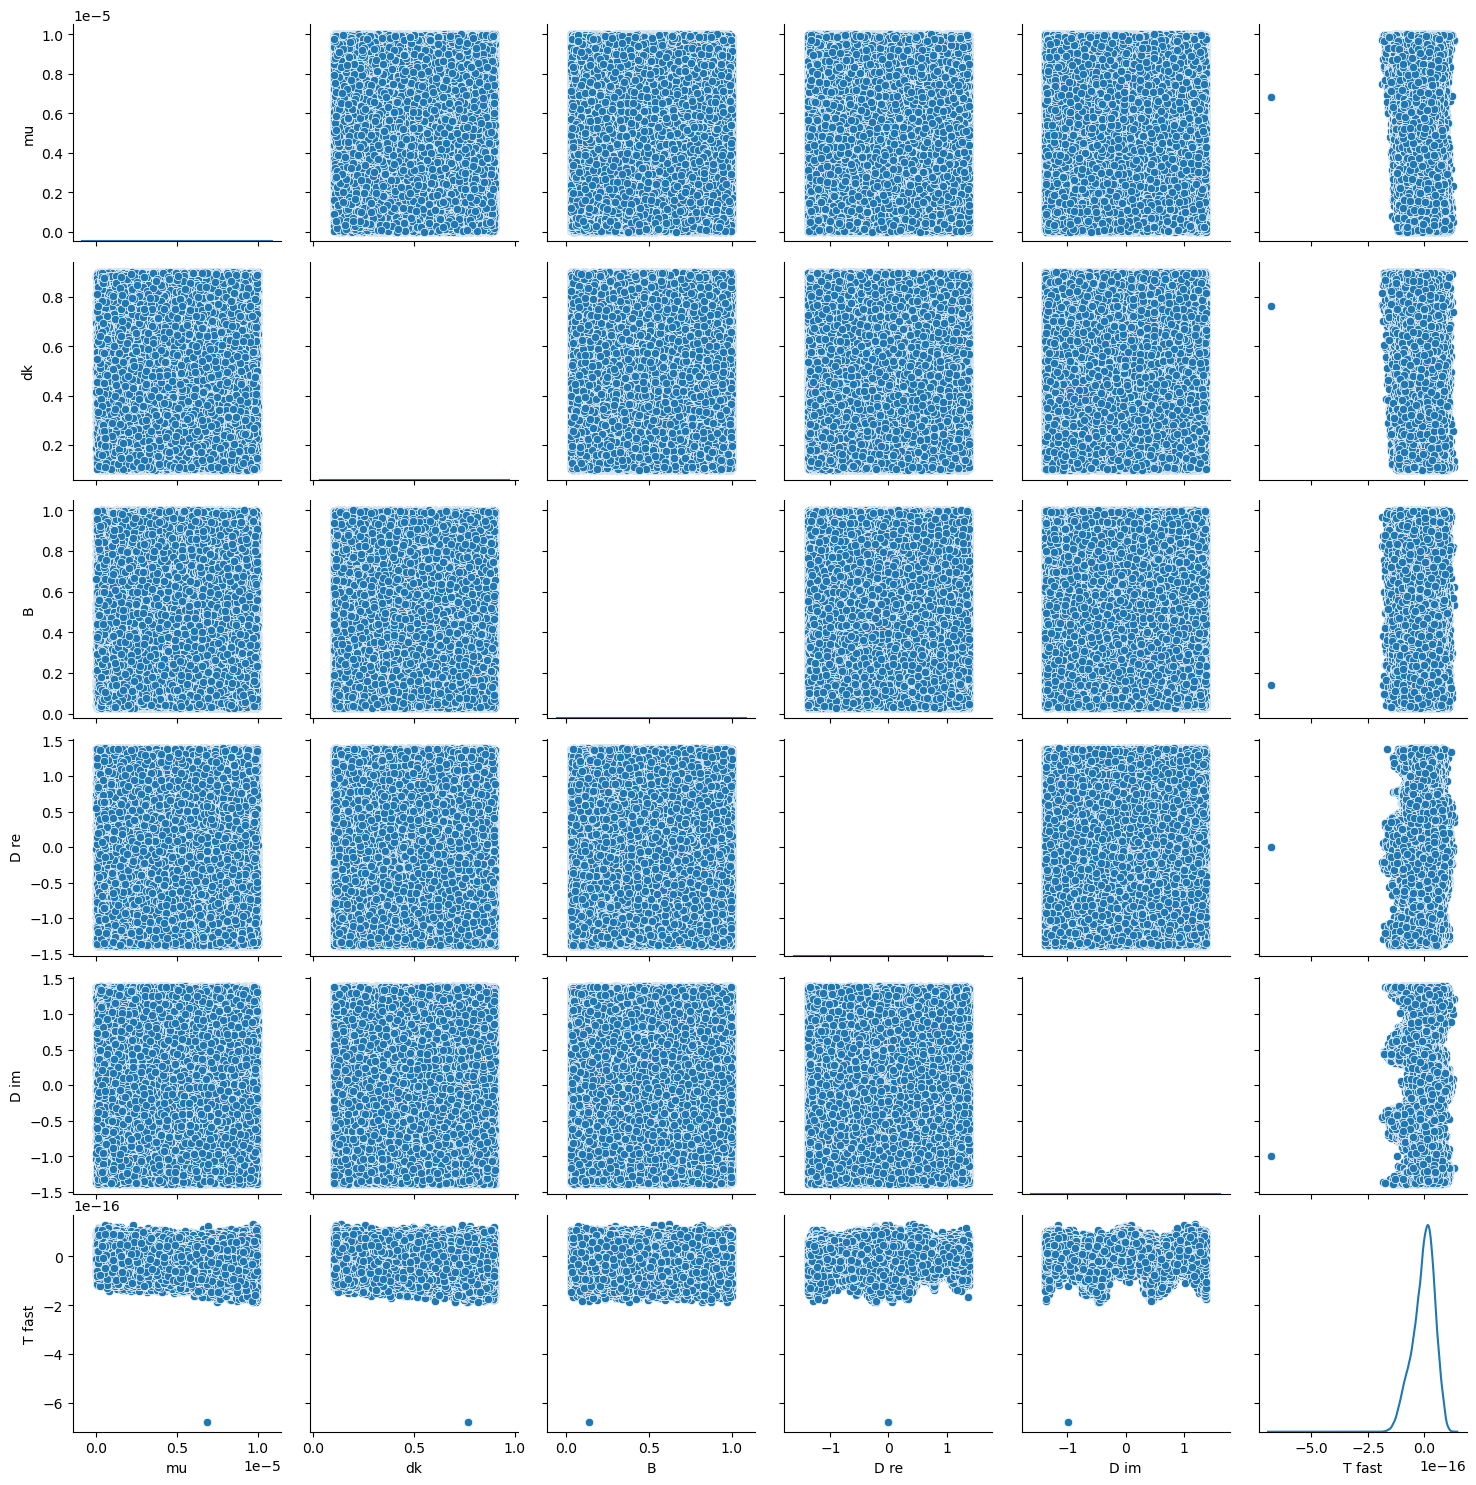

In [23]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

Patterns in the data are no longer as easy to see due to the random nature of our data, except for the shape of the error in the last plot. Our model, however, appears to work well. There are definitely patterns in the data, they are just not so easy to pick out visually.

There is one point with a suspiciously large error. Everything else is within tolerance. The large error point is on the edge of tolerance. Of note is $\Psi^\prime_0$, with a near-zero D_re and around -1 for D_im. The -6.8e-16 level for difference is around the level of my systematic error. If I correctly count the signs, it is doubling the error, but the opposite is in theory possible. I don't think this point is of concern due to the rarity of occurance, but I should be careful and aware of the existance of outliers.

Again patterns in the data appear. The difference is most likely independent of $B$, while there is a slight linear $\mu$ and $k$ dependence. $\Psi^\prime_0$ dependencies exist, most (but probably not all) are symmetric around $0$, and the form is not a simple polynomical or sinusoid.

In [24]:
np.max(npaf[:,5]), np.min(npaf[:,5])

(1.3023291907826732e-16, -6.767922050406004e-16)

In [25]:
np.argmin(npaf[:,5])

44042

In [26]:
np.min(npaf[:44042,5]), np.min(npaf[44043:,5])

(-1.882188734169265e-16, -1.8839606873902515e-16)

Definitely only one point in 100000.

In [27]:
npaf[44042]

array([ 6.83777815e-06,  7.65138418e-01,  1.40904977e-01, -7.01686696e-04,
       -9.97880750e-01, -6.76792205e-16])

The values don't really look special. Strange. I expected some sort of edge case. Well, the error is chaotic, so perhaps it is just chance. I just need to be aware that the error doesn't always work as expected. Maybe there is some sort of near-zero angle or denominator for which I am unaware ... 

**Old**

Error within expected range. Model works as expected. $A_0$ and $R$ can be accommodated by a rescaling of parameters (except for error modeling). $R$ definitely needs to be checked at some point, due to error, but is irrelevant right now. I would like to try a large run, then look at $A_0$ and $R$, then I need to try to vary $k_0$, then calculate $\Delta M$. 

There is also an error term independent of $\mu$. I should model this based on comparing the exact and numerical solutions for the version without ee interaction. This should be done on the grid again.

# Model Testing (Old)

In [13]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.2283477222352397e-16, -1.6455419903341496e-16)

In [14]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

8000


In [15]:
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

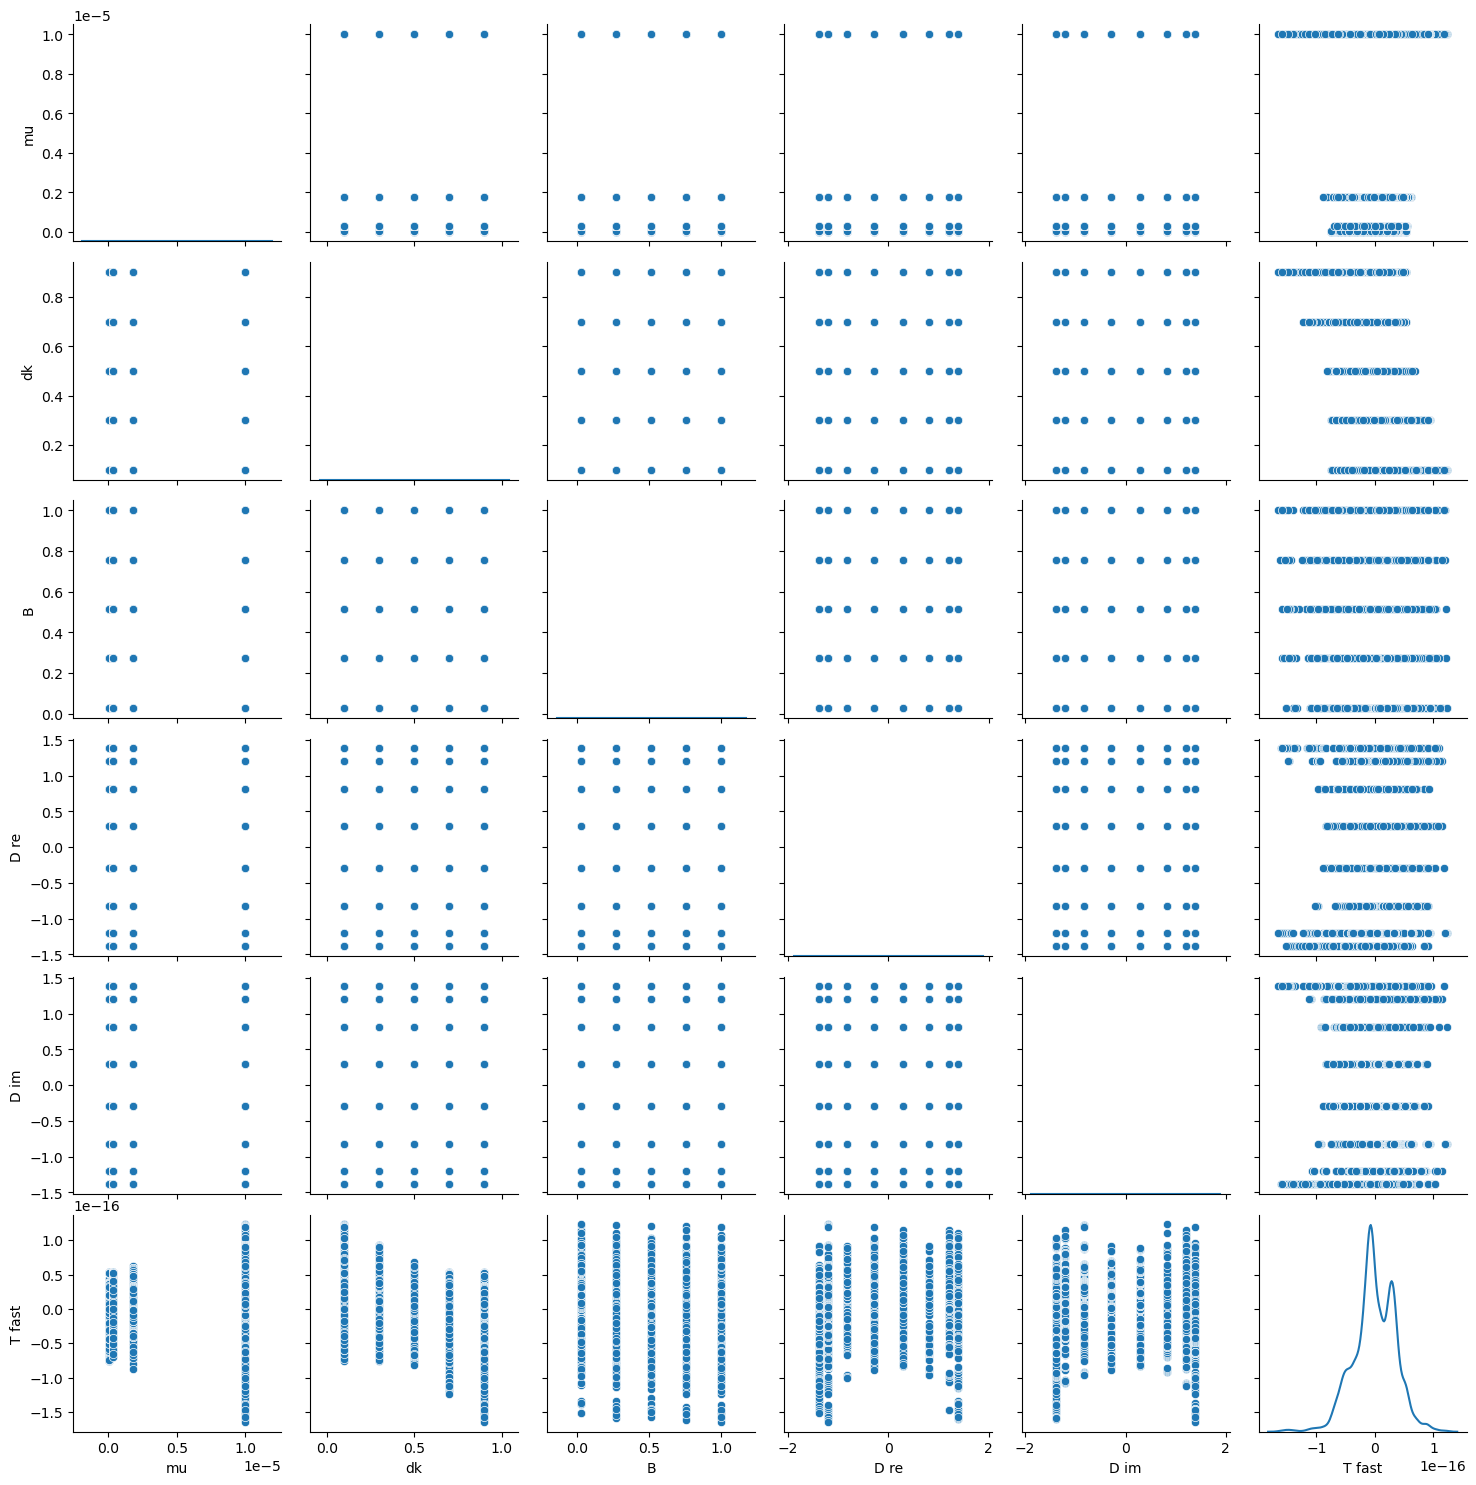

In [16]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

There are signals here, but I hope that we are already within tolerance. Linear, quadratic, and quartic terms are visible. Taylor expansion approximations work great here. 